<a href="https://colab.research.google.com/github/udlbook/udlbook/blob/main/Notebooks/Chap08/8_3_Double_Descent.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Notebook 8.3: Double Descent**

This notebook investigates double descent as described in section 8.4 of the book.

It uses the MNIST-1D database which can be found at https://github.com/greydanus/mnist1d

Work through the cells below, running each cell in turn. In various places you will see the words "TODO". Follow the instructions at these places and make predictions about what is going to happen or write code to complete the functions.

Contact me at udlbookmail@gmail.com if you find any mistakes or have any suggestions.

In [2]:
import torch, torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader
from torch.optim.lr_scheduler import StepLR
import numpy as np
import matplotlib.pyplot as plt
import mnist1d
import random
random.seed(0)

# Try attaching to GPU -- Use "Change Runtime Type to change to GPUT"
DEVICE = str(torch.device('cuda' if torch.cuda.is_available() else 'cpu'))
print('Using:', DEVICE)

Using: cuda


In [3]:
args = mnist1d.data.get_dataset_args()
args.num_samples = 8000
args.train_split = 0.5
args.corr_noise_scale = 0.25
args.iid_noise_scale=2e-2
data = mnist1d.data.get_dataset(args, path='./mnist1d_data.pkl', download=False, regenerate=True)

# Add 15% noise to training labels
for c_y in range(len(data['y'])):
    random_number = random.random()
    if random_number < 0.15 :
        random_int = int(random.random() * 10)
        data['y'][c_y] = random_int

# The training and test input and outputs are in
# data['x'], data['y'], data['x_test'], and data['y_test']
print("Examples in training set: {}".format(len(data['y'])))
print("Examples in test set: {}".format(len(data['y_test'])))
print("Dimensionality of each example: {}".format(data['x'].shape[-1]))

Did or could not load data from ./mnist1d_data.pkl. Rebuilding dataset...
Examples in training set: 4000
Examples in test set: 4000
Dimensionality of each example: 40


In [4]:
# Initialize the parameters with He initialization
def weights_init(layer_in):
  if isinstance(layer_in, nn.Linear):
    nn.init.kaiming_uniform_(layer_in.weight)
    layer_in.bias.data.fill_(0.0)

# Return an initialized model with two hidden layers and n_hidden hidden units at each
def get_model(n_hidden):

  D_i = 40    # Input dimensions
  D_k = n_hidden   # Hidden dimensions
  D_o = 10    # Output dimensions

  # Define a model with two hidden layers
  # And ReLU activations between them
  model = nn.Sequential(
  nn.Linear(D_i, D_k),
  nn.ReLU(),
  nn.Linear(D_k, D_k),
  nn.ReLU(),
  nn.Linear(D_k, D_o))

  # Call the function you just defined
  model.apply(weights_init)

  # Return the model
  return model ;

In [5]:
def fit_model(model, data, n_epoch):

  # choose cross entropy loss function (equation 5.24)
  loss_function = torch.nn.CrossEntropyLoss()
  # construct SGD optimizer and initialize learning rate and momentum
  # optimizer = torch.optim.Adam(model.parameters(), lr=0.01)
  optimizer = torch.optim.SGD(model.parameters(), lr = 0.01, momentum=0.9)


  x_train = torch.tensor(data['x'].astype('float32'))
  y_train = torch.tensor(data['y'].transpose().astype('long'))
  x_test= torch.tensor(data['x_test'].astype('float32'))
  y_test = torch.tensor(data['y_test'].astype('long'))

  # load the data into a class that creates the batches
  data_loader = DataLoader(TensorDataset(x_train,y_train), batch_size=100, shuffle=True, worker_init_fn=np.random.seed(1))

  for epoch in range(n_epoch):
    # loop over batches
    for i, batch in enumerate(data_loader):
      # retrieve inputs and labels for this batch
      x_batch, y_batch = batch
      # zero the parameter gradients
      optimizer.zero_grad()
      # forward pass -- calculate model output
      pred = model(x_batch)
      # compute the loss
      loss = loss_function(pred, y_batch)
      # backward pass
      loss.backward()
      # SGD update
      optimizer.step()

    # Run whole dataset to get statistics -- normally wouldn't do this
    pred_train = model(x_train)
    pred_test = model(x_test)
    _, predicted_train_class = torch.max(pred_train.data, 1)
    _, predicted_test_class = torch.max(pred_test.data, 1)
    errors_train = 100 - 100 * (predicted_train_class == y_train).float().sum() / len(y_train)
    errors_test= 100 - 100 * (predicted_test_class == y_test).float().sum() / len(y_test)
    losses_train = loss_function(pred_train, y_train).item()
    losses_test= loss_function(pred_test, y_test).item()
    if epoch%100 ==0 :
      print(f'Epoch {epoch:5d}, train loss {losses_train:.6f}, train error {errors_train:3.2f},  test loss {losses_test:.6f}, test error {errors_test:3.2f}')

  return errors_train, errors_test


In [6]:
def count_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

The following code produces the double descent curve by training the model with different numbers of hidden units and plotting the test error.

TODO:

*Before* you run the code, and considering that there are 4000 training examples predict:<br>

1.    At what capacity do you think the training error will become zero?
Teniendo en mente que la dimensión de entrada es 40, y la de salida es 10, probablemente en algo menor o igual a 50, pues el modelo ya debería tener suficientes folds para poder hacer overfitting, por seguridad pensaría que en 50.

2.   At what capacity do you expect the first minima of the double descent curve to appear?
Algo que acceda por mucho la capacidad necesaria, si 50 ya debe estar en el punto que lo supera, entonces el doble 100.

3. At what capacity do you expect the maximum of the double descent curve to appear?
Pensaria que ya serca al final del arreglo asi que diria que 200.

In [ ]:
# This code will take a while (~30 mins on GPU) to run!  Go and make a cup of coffee!
# My GPU is cooked
hidden_variables = np.array([2,4,6,8,10,14,18,22,26,30,35,40,45,50,55,60,70,80,90,100,120,140,160,180,200,250,300,400]) ;

errors_train_all = np.zeros_like(hidden_variables)
errors_test_all = np.zeros_like(hidden_variables)
total_weights_all = np.zeros_like(hidden_variables)

# loop over the dataset n_epoch times
n_epoch = 1000

# For each hidden variable size
for c_hidden in range(len(hidden_variables)):
    print(f'Training model with {hidden_variables[c_hidden]:3d} hidden variables')
    # Get a model
Bueno respecto a las estimaciones si era cierto el sentido de que 50 ya debía exceder la capacidad necesaria,  efectivamente el error 0 está ahí, aunque no relacione que el máximo de la doble curva de descenso estaba cerca, y la pregunta 2 igual es un poco difícil ver donde aparece el segundo minimo pero igual no parece una estimación muy mala.

    model = get_model(hidden_variables[c_hidden]) ;
    # Count and store number of weights
    total_weights_all[c_hidden] = count_parameters(model)
    # Train the model
    errors_train, errors_test = fit_model(model, data, n_epoch)
    # Store the results
    errors_train_all[c_hidden] = errors_train
    errors_test_all[c_hidden]= errors_test



Training model with   2 hidden variables
Epoch     0, train loss 2.299429, train error 88.62,  test loss 2.301109, test error 88.68
Epoch   100, train loss 2.014050, train error 78.80,  test loss 1.924062, test error 76.28
Epoch   200, train loss 1.914604, train error 72.38,  test loss 1.788910, test error 70.65
Epoch   300, train loss 1.861775, train error 70.32,  test loss 1.712285, test error 68.72
Epoch   400, train loss 1.858321, train error 70.30,  test loss 1.706314, test error 68.20
Epoch   500, train loss 1.860049, train error 70.65,  test loss 1.709382, test error 68.80
Epoch   600, train loss 1.867819, train error 71.60,  test loss 1.705475, test error 69.50
Epoch   700, train loss 1.855712, train error 70.28,  test loss 1.705931, test error 68.78
Epoch   800, train loss 1.861102, train error 71.12,  test loss 1.705296, test error 69.32
Epoch   900, train loss 1.858162, train error 70.82,  test loss 1.715513, test error 69.90
Training model with   4 hidden variables
Epoch   

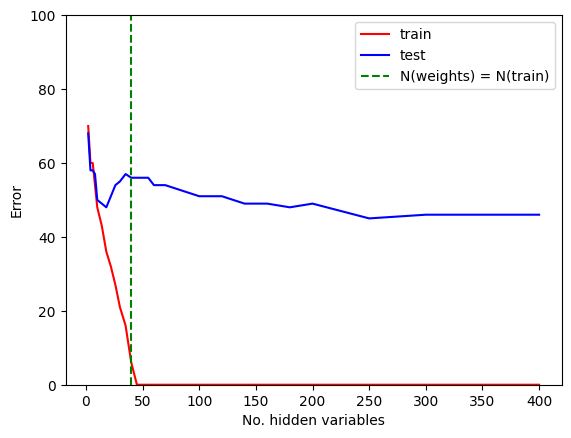

In [8]:
import matplotlib.pyplot as plt
import numpy as np

# Assuming data['y'] is available and contains the training examples
num_training_examples = len(data['y'])

# Find the index where total_weights_all is closest to num_training_examples
closest_index = np.argmin(np.abs(np.array(total_weights_all) - num_training_examples))

# Get the corresponding value of hidden variables
hidden_variable_at_num_training_examples = hidden_variables[closest_index]

# Plot the results
fig, ax = plt.subplots()
ax.plot(hidden_variables, errors_train_all, 'r-', label='train')
ax.plot(hidden_variables, errors_test_all, 'b-', label='test')

# Add a vertical line at the point where total weights equal the number of training examples
ax.axvline(x=hidden_variable_at_num_training_examples, color='g', linestyle='--', label='N(weights) = N(train)')

ax.set_ylim(0, 100)
ax.set_xlabel('No. hidden variables')
ax.set_ylabel('Error')
ax.legend()
plt.show()


Bueno respecto a las estimaciones si era cierto el sentido de que 50 ya debía exceder la capacidad necesaria,  efectivamente el error 0 está ahí, aunque no relacione que el máximo de la doble curva de descenso estaba cerca, y la pregunta 2 igual es un poco difícil ver donde aparece el segundo minimo pero igual no parece una estimación muy mala.